# Visualisation of inference for the AB-SWIFT case

This notebook provides a visualisation of AB-SWIFT predictions for RoPE and LAAPE embeddings for different scaling

## Setup

In [ ]:
# imports ect

%load_ext autoreload
%autoreload 2
%matplotlib ipympl

import sys
from pathlib import Path

import numpy as np

import torch
from torch.utils.data import DataLoader

from noether.inference import Run  # noqa: E402

import matplotlib.pyplot as plt
import cmocean

#add path to code in path
_p = Path.cwd().resolve()
_experiments = _p / ".." / "experiments"
if _experiments.exists() and str(_experiments) not in sys.path:
    sys.path.insert(0, str(_experiments))

from abswift.datasets.vtk_tools import get_slice


RUN_DIR_LAAPE = Path("../experiments/abswift/outputs/abswift_laape/train")
RUN_DIR_ROPE  = Path("../experiments/abswift/outputs/abswift_rope/train")

DATASET_ROOT = Path("../data/random_buildings_dataset")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# Plot function

def plot_prediction_comparaison(tri, field_true, prediction_1, prediction_2,
                          velocity_unit="m/s"):
    '''Plot the predictions side by side'''

    lbl1, field_pred1 = prediction_1
    lbl2, field_pred2 = prediction_2

    # Compute norms
    def norm(v):
        return np.linalg.norm(v, axis=1)

    n_true = norm(field_true)
    n_p1 = norm(field_pred1)
    n_p2 = norm(field_pred2)

    # Shared color limits
    vmin = min(n_true.min(), n_p1.min(), n_p2.min())
    vmax = max(n_true.max(), n_p1.max(), n_p2.max())

    fig, axs = plt.subplots(1,3,
                            sharex=True, sharey=True,
                            layout = 'constrained', 
                            subplot_kw = dict(aspect='equal'),
                            figsize=(12,6)
    )

    im0 = axs[0].tripcolor(tri, n_true, cmap=cmocean.cm.deep, vmin=vmin, vmax=vmax)
    axs[0].set_title("Ground truth")

    axs[1].tripcolor(tri, n_p1, cmap=cmocean.cm.deep, vmin=vmin, vmax=vmax)
    axs[1].set_title(lbl1)

    axs[2].tripcolor(tri, n_p2, cmap=cmocean.cm.deep, vmin=vmin, vmax=vmax)
    axs[2].set_title(lbl2)

    # Shared colorbar
    cbar = fig.colorbar(im0, ax=axs, shrink = 0.3)
    cbar.set_label(f"Velocity [{velocity_unit}]")

    return fig, axs

In [3]:
# Load the trained models, the datasets and the pipeline

#RoPE: just the model is enough
ckpt_path = RUN_DIR_ROPE
ckpt_run = Run.from_checkpoint(ckpt_path / 'checkpoints' / 'abswift_cp=latest_model.th')
model_rope = ckpt_run.model(device=DEVICE)

#Laape: We load the full run to access the datasets and pipelines
run = Run(RUN_DIR_LAAPE)

#model
model_laape = run.model(checkpoint='latest', device=DEVICE)

# test splits of dataset were not included in the training config, so we add them
# We also need to scale the number of supernodes and key points by the scaling factor of each split
for split, s in zip(['neutral_test_subset', 'large_scale_test', 'very_large_scale_test'], [1,2,5]):
    #add the split to config
    run.config.datasets[split] = run.config.datasets['train'].model_copy(deep=True)
    run.config.datasets[split].split = split
    run.config.datasets[split].pipeline = run.config.datasets['train'].pipeline.model_copy(deep=True)
    #scale the pipeline
    s2 = s**2
    run.config.datasets[split].pipeline.num_terrain_points = run.config.datasets['train'].pipeline.num_terrain_points * s2
    run.config.datasets[split].pipeline.num_obstacles_points = run.config.datasets['train'].pipeline.num_obstacles_points * s2
    run.config.datasets[split].pipeline.num_terrain_supernodes = run.config.datasets['train'].pipeline.num_terrain_supernodes * s2
    run.config.datasets[split].pipeline.num_obstacles_supernodes = run.config.datasets['train'].pipeline.num_obstacles_supernodes * s2
    run.config.datasets[split].pipeline.num_volume_anchor_points = run.config.datasets['train'].pipeline.num_volume_anchor_points * s2

# Point each split's dataset at the local data root.
for ds_cfg in run.config.datasets.values():
    ds_cfg.root = str(DATASET_ROOT)

#builds the datasets
datasets = dict(
    neutral_test_subset = run.dataset('neutral_test_subset'),
    large_scale_test = run.dataset('large_scale_test'),
    very_large_scale_test = run.dataset('very_large_scale_test')
)

#finally build the normalisers (same for all splits)
norms = run.normalizers('train')

In [4]:
# Inference function
# To lighten the load for large scale test, we only want to query the points we are plotting (not the full volumic mesh)
# This is particularly important for the very_large_scale_test split, which is somewhat heavy to run locally if no GPUs are available

def inference(model, split: str, idx: int, query_points: torch.Tensor) -> dict[str:torch.Tensor]:
    '''Forward pass through the model'''

    fwd_keys = ['obstacles_position',
                'obstacles_supernode_idx',
                'obstacles_batch_idx',
                'terrain_position',
                'terrain_supernode_idx',
                'terrain_batch_idx',
                'terrain_features',
                'anchor_volume_position',
                'query_volume_position',
                'meteorological_profile']

    data = datasets[split][idx]
    batch = datasets[split].pipeline([data])

    #add query points (with batch dim and normalisation)
    batch['query_volume_position'] = norms['positions'](query_points).unsqueeze(0)

    missing = [k for k in fwd_keys if k not in batch]
    if missing:
        raise KeyError(f"batch missing expected forward keys: {missing}. Got: {sorted(batch)}")

    inputs = {k: batch[k].to(DEVICE) for k in fwd_keys}

    with torch.inference_mode():
        preds = model(**inputs)

    # filter out predictions at anchors, we are nonly interested in the queries
    # And also filter out 'query' from the key name
    preds = {k[6:]:v for k,v in preds.items() if 'query' in k}    

    #remove batch dim + send to cpu
    preds = {k:v[0].cpu() for k,v in preds.items()}

    #denormalise
    preds = {k:norms[k].inverse(v) for k,v in preds.items()}

    return preds


In [5]:
def run_comparaison(split, idx, height = 2):
    '''Run the inferences and plot the result'''

    dataset = datasets[split]
    mesh = dataset.get_volume_mesh(idx)

    #2D horizontal slice
    triang, ids = get_slice(mesh, height)

    #get the query coords and the raw data
    query_coords = dataset._data[idx]['volume_position'][ids]
    gt_velocity = dataset._data[idx]['volume_velocity'][ids]

    #forward pass of both models
    rope_velocity  = inference(model_rope,  split, idx, query_coords)['volume_velocity']
    laape_velocity = inference(model_laape, split, idx, query_coords)['volume_velocity']

    #generate the plot
    fig, _ = plot_prediction_comparaison(
            triang,
            gt_velocity,
            ('RoPE', rope_velocity),
            ('LAAPE', laape_velocity)
    )

    return fig

## Comparaisons

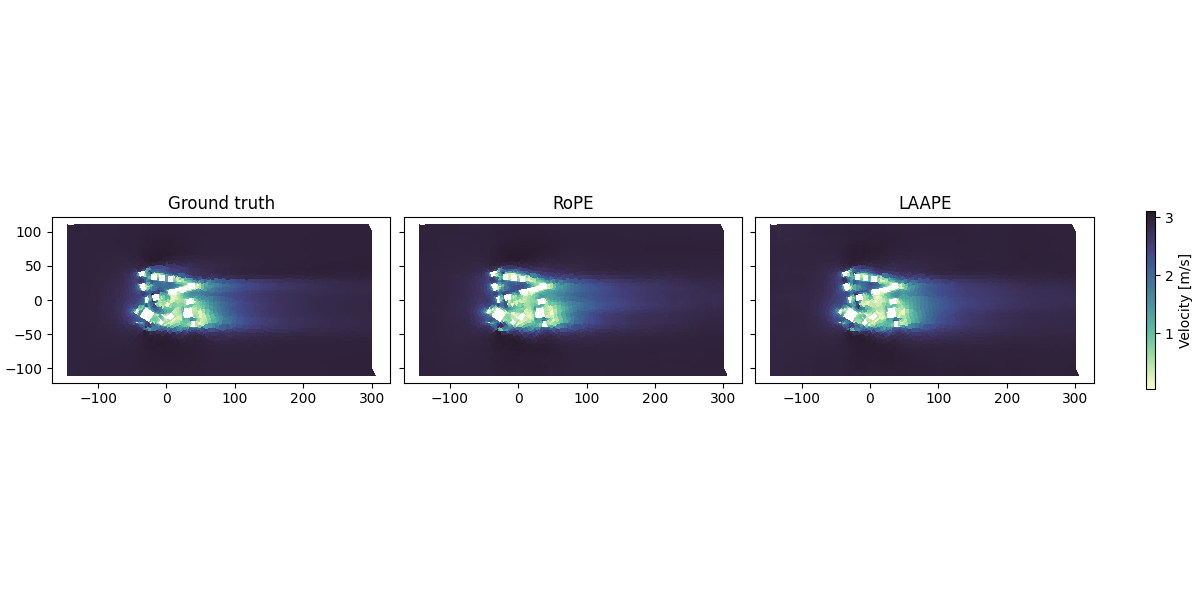

In [6]:
# scale 1

# neutral_test_subset is a subset of the rbd test split containing only neutral cases
# for a fair comparaison with large scale tests which are all in neutral atmo conditions
split = 'neutral_test_subset'
idx = 0

fig = run_comparaison(split, idx)

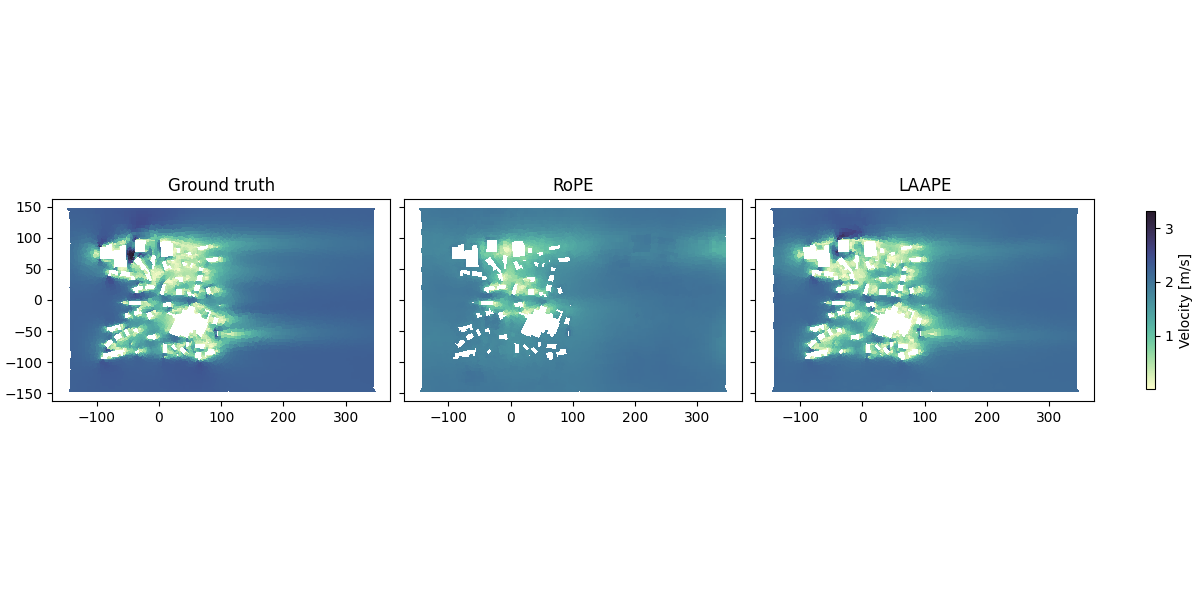

In [7]:
# scale 2

split = 'large_scale_test'
idx = 0

fig = run_comparaison(split, idx)

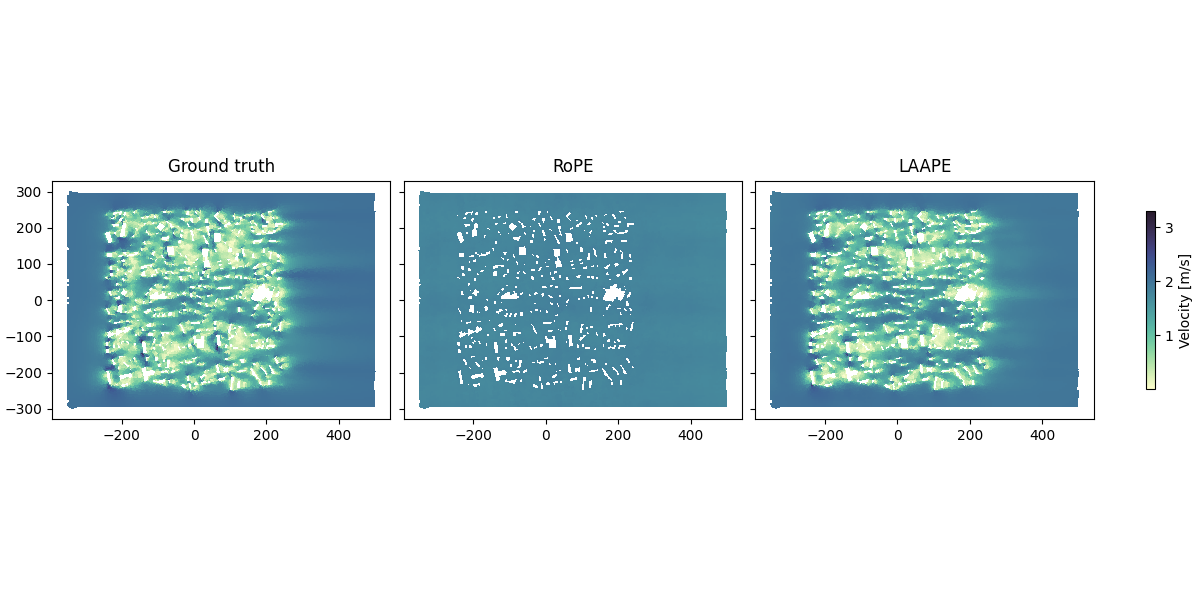

In [8]:
# scale 5

split = 'very_large_scale_test'
idx = 4

fig = run_comparaison(split, idx)